This will compare the values access via the native netcdf files versus via the virtual dataset.

In [3]:
# Built-in packages
import os
import sys
import shutil

# Filesystem management 
import fsspec
import earthaccess

# Data handling
import numpy as np
import xarray as xr

# Parallel computing 
import multiprocessing
from dask import delayed
import dask.array as da
from dask.distributed import Client
import coiled

# Other
import matplotlib.pyplot as plt

In [38]:
earthaccess.login()

### Load data from VDS

In [39]:
def get_vds_mapper(vds_link, in_cloud_region=False):
    """
    Produces a virtudal dataset mapper that can be passed to xarray. 
    
    * vds_link: str, link to the mapper
    * in_cloud_region: bool, True if in cloud in the same region as the data, 
        False otherwise.
    """

    if in_cloud_region:
        fs_data = earthaccess.get_s3_filesystem(daac="PODAAC")
        remote_protocol = "s3"
    else:
        fs_data = earthaccess.get_fsspec_https_session()
        remote_protocol = "https"
    
    storage_opts = {"fo": vds_link, "remote_protocol": remote_protocol, "remote_options": fs_data.storage_options}
    fs_ref = fsspec.filesystem('reference', **storage_opts)
    return fs_ref.get_mapper('')

In [10]:
# in_cloud_region = False # Set to true if you are in the same cloud region as the data, otherwise set to false

In [11]:
# if in_cloud_region:
#     fs = earthaccess.get_s3_filesystem(daac="PODAAC")
#     remote_protocol = "s3"
# else:
#     fs = earthaccess.get_fsspec_https_session()
#     remote_protocol = "https"

# storage_opts = {
#     "remote_protocol": remote_protocol,
#     "remote_options": fs.storage_options
# }

In [61]:
shortname = "SMAP_RSS_L3_SSS_SMI_8DAY-RUNNINGMEAN_V6"
vds_link = "./SMAP_RSS_L3_SSS_SMI_8DAY-RUNNINGMEAN_V6_virtual_s3.json"
vds_mapper = get_vds_mapper(vds_link, in_cloud_region=True)

In [62]:
data_vds = xr.open_dataset(
    vds_mapper, engine="zarr", chunks={},
    backend_kwargs={"consolidated": False}
)
data_vds

<xarray.Dataset> Size: 1TB
Dimensions:                 (time: 3676, lat: 720, lon: 1440,
                             iceflag_components: 3, uncertainty_components: 9)
Coordinates:
  * lat                     (lat) float32 3kB -89.88 -89.62 ... 89.62 89.88
  * lon                     (lon) float32 6kB 0.125 0.375 0.625 ... 359.6 359.9
  * time                    (time) datetime64[ns] 29kB 2015-04-01T12:00:00 .....
Dimensions without coordinates: iceflag_components, uncertainty_components
Data variables: (12/19)
    anc_sea_ice_flag        (time, lat, lon, iceflag_components) float32 46GB dask.array<chunksize=(1, 720, 1440, 2), meta=np.ndarray>
    fland                   (time, lat, lon) float64 30GB dask.array<chunksize=(1, 720, 1440), meta=np.ndarray>
    gice_est                (time, lat, lon) float64 30GB dask.array<chunksize=(1, 720, 1440), meta=np.ndarray>
    gland                   (time, lat, lon) float64 30GB dask.array<chunksize=(1, 720, 1440), meta=np.ndarray>
    nobs                    (time, lat, lon) float64 30GB dask.array<chunksize=(1, 720, 1440), meta=np.ndarray>
    nobs_40km               (time, lat, lon) float64 30GB dask.array<chunksize=(1, 720, 1440), meta=np.ndarray>
    ...                      ...
    sss_smap_RF             (time, lat, lon) float64 30GB dask.array<chunksize=(1, 720, 1440), meta=np.ndarray>
    sss_smap_RF_unc         (time, lat, lon) float64 30GB dask.array<chunksize=(1, 720, 1440), meta=np.ndarray>
    sss_smap_unc            (time, lat, lon) float64 30GB dask.array<chunksize=(1, 720, 1440), meta=np.ndarray>
    sss_smap_unc_comp       (time, uncertainty_components, lat, lon) float64 274GB dask.array<chunksize=(1, 3, 240, 480), meta=np.ndarray>
    surtep                  (time, lat, lon) float64 30GB dask.array<chunksize=(1, 720, 1440), meta=np.ndarray>
    winspd                  (time, lat, lon) float64 30GB dask.array<chunksize=(1, 720, 1440), meta=np.ndarray>
Attributes: (12/55)
    Conventions:                                            CF-1.7, ACDD-1.3
    Source_of_SMAP_SSS_retrievals:                          T. Meissner, F. W...
    Source_of_ancillary_AMSR2_sea_ice_flag_and_correction:  Meissner, T. and ...
    Source_of_ancillary_CCMP_wind_speed:                    Mears, C. et al.,...
    Source_of_ancillary_SST:                                Canada Meteorolog...
    Source_of_ancillary_land_mask:                          1 km land/water m...
    ...                                                     ...
    standard_name_vocabulary:                               CF Standard Name ...
    summary:                                                The dataset conta...
    time_coverage_duration:                                 P8D
    time_coverage_resolution:                               P8D
    title:                                                  SMAP ocean surfac...
    version:                                                V6.0 Validated Re...

In [17]:
# data_vds = xr.open_dataset(
#     vds_link,
#     engine="kerchunk",
#     chunks={},
#     backend_kwargs={
#         "storage_options": storage_opts
#     }
# )
# data_vds

### Load data from native files

In [63]:
granule_info = earthaccess.search_data(short_name=shortname, count=9000)
file_objs_native = earthaccess.open(granule_info)

QUEUEING TASKS | :   0%|          | 0/3676 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/3676 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/3676 [00:00<?, ?it/s]

In [64]:
data_native = xr.open_dataset(file_objs_native[0])
data_native

<xarray.Dataset> Size: 153MB
Dimensions:                 (lon: 1440, lat: 720, time: 1,
                             uncertainty_components: 9, iceflag_components: 3)
Coordinates:
  * lon                     (lon) float32 6kB 0.125 0.375 0.625 ... 359.6 359.9
  * lat                     (lat) float32 3kB -89.88 -89.62 ... 89.62 89.88
  * time                    (time) datetime64[ns] 8B 2015-04-01T12:00:00
Dimensions without coordinates: uncertainty_components, iceflag_components
Data variables: (12/19)
    nobs                    (lat, lon) float64 8MB ...
    nobs_RF                 (lat, lon) float64 8MB ...
    nobs_40km               (lat, lon) float64 8MB ...
    sss_smap                (lat, lon) float32 4MB ...
    sss_smap_RF             (lat, lon) float32 4MB ...
    sss_smap_unc            (lat, lon) float32 4MB ...
    ...                      ...
    fland                   (lat, lon) float32 4MB ...
    gice_est                (lat, lon) float32 4MB ...
    surtep                  (lat, lon) float32 4MB ...
    winspd                  (lat, lon) float32 4MB ...
    sea_ice_zones           (lat, lon) int8 1MB ...
    anc_sea_ice_flag        (lat, lon, iceflag_components) int8 3MB ...
Attributes: (12/65)
    Conventions:                                            CF-1.7, ACDD-1.3
    title:                                                  SMAP ocean surfac...
    version:                                                V6.0 Validated Re...
    summary:                                                The dataset conta...
    acknowledgement:                                        Funded under Subc...
    processing_level:                                       L3
    ...                                                     ...
    Source_of_SMAP_SSS_retrievals:                          T. Meissner, F. W...
    Source_of_ancillary_SST:                                Canada Meteorolog...
    Source_of_ancillary_CCMP_wind_speed:                    Mears, C. et al.,...
    Source_of_ancillary_AMSR2_sea_ice_flag_and_correction:  Meissner, T. and ...
    Source_of_ancillary_land_mask:                          1 km land/water m...
    Source_of_ancillary_reference_SSS_from_HYCOM:           Hybrid Coordinate...

### Compare, take difference between array subsets and quantify percent difference

In [82]:
def compare_vds_native(
    data_vds, data_native, varname, 
    time_index, lon_bounds, lat_bounds,
    timevar="time", lonvar="longitude", latvar="latitude"):
    """
    Assumes:
    1. "data_native" is an xarray Dataset for the collection at a singe timestep, corresponding to the 
        time_index'th stamp of "data_vds", which is the VDS for the whole collection.
    2. The first time stamp of "data_native" is the same as the time_index'th stamp of "data_vds".
    """
    
    var_vds = data_vds[varname]
    var_subset_vds = var_vds.isel({timevar:time_index}).sel({latvar:slice(*lat_bounds), lonvar:slice(*lon_bounds)})
    var_subset_vds = var_subset_vds.compute()

    data_subset_native = data_native.isel({timevar:0}).sel({latvar:slice(*lat_bounds), lonvar:slice(*lon_bounds)})
    var_subset_native = data_subset_native[varname]
    #var_native = data_native[varname]
    #var_subset_native = var_native.isel({timevar:0}).sel({latvar:slice(*lat_bounds), lonvar:slice(*lon_bounds)})

    print("VDS data timestamp", var_subset_vds[timevar].values)
    print("Native data timestamp", var_subset_native[timevar].values)

    diff = var_subset_vds - var_subset_native
    plt.figure
    plt.hist(diff.values.flatten())

VDS data timestamp 2015-04-01T12:00:00.000000000
Native data timestamp 2015-04-01T12:00:00.000000000


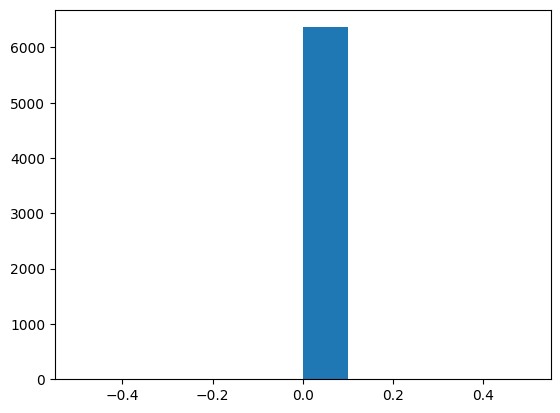

In [83]:
data_native = xr.open_dataset(file_objs_native[0])
compare_vds_native(data_vds, data_native, "sss_smap", 0, (340,360), (-20,0), lonvar="lon", latvar="lat")

VDS data timestamp 2017-06-17T12:00:00.000000000
Native data timestamp 2017-06-17T12:00:00.000000000


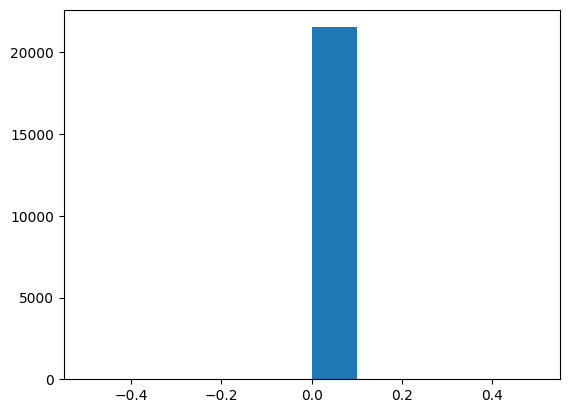

In [84]:
data_native = xr.open_dataset(file_objs_native[808])
compare_vds_native(data_vds, data_native, "nobs_40km", 808, (200,230), (0,45), lonvar="lon", latvar="lat")

VDS data timestamp 2021-03-02T12:00:00.000000000
Native data timestamp 2021-03-02T12:00:00.000000000


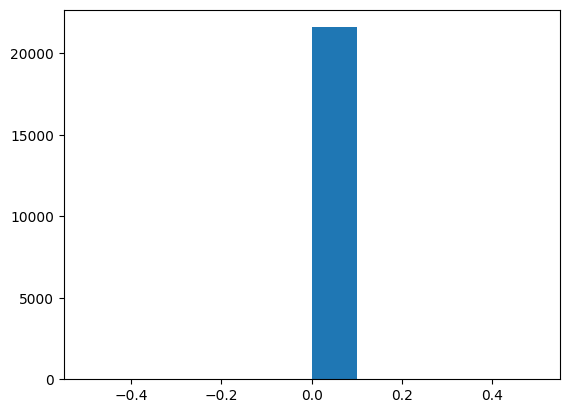

In [85]:
data_native = xr.open_dataset(file_objs_native[2123])
compare_vds_native(data_vds, data_native, "winspd", 2123, (200,230), (-45,0), lonvar="lon", latvar="lat")

In [54]:
granule_info = earthaccess.search_data(short_name=shortname, count=9000)
#file_objs_native = earthaccess.open(granule_info)

In [55]:
file_objs_native = earthaccess.open(granule_info[-100:])

QUEUEING TASKS | :   0%|          | 0/100 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/100 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/100 [00:00<?, ?it/s]

VDS data timestamp 2025-07-18T12:00:00.000000000
Native data timestamp 2025-07-18T12:00:00.000000000


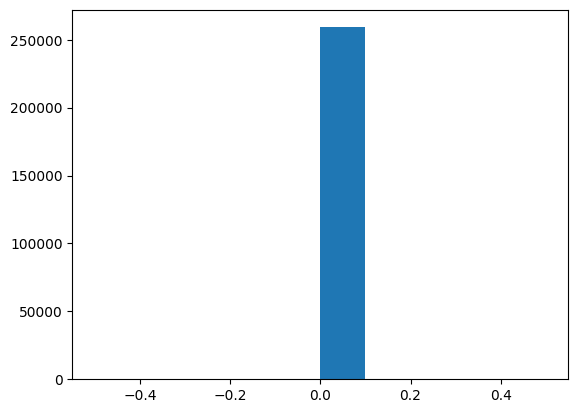

In [90]:
data_native = xr.open_dataset(file_objs_native[-2])
compare_vds_native(data_vds, data_native, "sea_ice_zones", -2, (180,360), (-90,0), lonvar="lon", latvar="lat")